# Laser power noise: DARK (laser-off) vs ON — floor-corrected, + PD-vs-power-meter check

Based on `laser_rin.ipynb` (same `load_h5` / `to_uW` / thermal-requirement / Welch methods),
but compares the **laser-on** 22 h PD record against a **laser-off (dark)** 22 h record.

- Both are 22 h → the Welch estimate reaches deep into the **0.3–10 mHz** requirement band.
- The dark record gives the **detector/electronic floor**, so we can quadrature-subtract it
  (→ the *true* laser power noise) and tag which spectral lines are electronic.
- The counts→mW calibration comes from the **Ophir StarLab meter** log over the same window
  (PD median counts / meter mean mW), so it is valid at **whatever power the run sat at**
  (this pair ≈ 3 mW). Point it at a higher-power pair later and it recalibrates itself.

**Data access:** on a laptop with the Dropbox folder synced, set `DATA_LOCAL` to the local
`.../Microspheres/TFINER` path — the files are then read directly. On the lab workstation
leave it `None` and the files are pulled from Dropbox via `rclone` into a local cache.

In [1]:
import os, subprocess, sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.signal import welch, find_peaks, correlate
from scipy.ndimage import median_filter, uniform_filter1d
%matplotlib inline

# ---- data sources -----------------------------------------------------------------
# LAPTOP: set DATA_LOCAL to your synced Dropbox path, e.g.
#   DATA_LOCAL = '/Users/you/Yale University Dropbox/David Moore/shared_drives/Microspheres/TFINER'
# LAB WORKSTATION: leave None -> files are rclone-pulled into ./_pd_cache
DATA_LOCAL = None
SUBDIR = {'PD': 'data/PD', 'POWER': 'laser_power'}
CACHE  = os.path.join(os.getcwd(), '_pd_cache')
RCLONE = os.path.expanduser('~/.local/bin/rclone')

ON_H5    = 'Y1_RDS-PD_IN1_DQ_1469307101_1469386301.h5'   # laser-on,  22 h (Jul 28-29)
DARK_H5  = 'Y1_RDS-PD_IN1_DQ_1469220701_1469299901.h5'   # laser-off, 22 h (Jul 27-28)
POWER_TXT = '260728_laser_power.txt'                      # Ophir StarLab log, 660 nm

# ---- memory tunables (records are 81 M samples) -----------------------------------
HI_HOURS, NPERSEG_HI = 2.0, 16384     # high-f: 2 h of full-rate data, 16 s segments
FS_LO, SEG_LO_S      = 16, 300        # low-f : block-averaged to 16 Hz, 300 s segments

# ---- constants (identical to laser_rin; TORQUE_PER_MW is gain-independent) ---------
GPS_UNIX_OFFSET = 315964800 - 18
def gps_to_dt(g): return datetime.fromtimestamp(g + GPS_UNIX_OFFSET, tz=timezone.utc)

KB_J, T_BATH = 1.380649e-23, 300.0
I_KGM2, TAU_FREE_S = 1.88e-11, 67.65 * 60.0
GAMMA = 1.0 / TAU_FREE_S
S_N_THERMAL = np.sqrt(4 * KB_J * T_BATH * GAMMA * I_KGM2)          # N m / sqrt(Hz)
TORQUE_PER_MW = 7.3499e-16 * (167.6 / 10.34)                       # N m per mW
REQ_UW    = S_N_THERMAL / TORQUE_PER_MW * 1e3                      # uW/sqrt(Hz)
TARGET_UW = 1.0
E_CHARGE, RESPONSIVITY = 1.602176634e-19, 0.7                      # A/W; adjust to diode

/tmp/ipykernel_1461074/2042220968.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.signal import welch, find_peaks, correlate


In [2]:
def ensure_local(kind, name):
    '''Return a local path to `name` (kind in {PD, POWER}). Prefer a synced DATA_LOCAL
    folder; otherwise rclone-pull from Dropbox into CACHE once and reuse.'''
    if DATA_LOCAL:
        p = os.path.join(DATA_LOCAL, SUBDIR[kind], name)
        if os.path.exists(p):
            return p
    os.makedirs(CACHE, exist_ok=True)
    local = os.path.join(CACHE, name)
    if not os.path.exists(local):
        print(f'  fetching {name} from Dropbox ...', flush=True)
        remote = f'dropbox:Microspheres/TFINER/{SUBDIR[kind]}/{name}'
        if subprocess.run([RCLONE, 'copyto', remote, local]).returncode or not os.path.exists(local):
            sys.exit(f'ERROR: could not obtain {name}')
    return local


def load_h5(path):
    '''Segment-aware read (from laser_rin.ipynb; float32 for memory). Returns (t, y, fs).'''
    ts, ys = [], []
    with h5py.File(path, 'r') as f:
        fs = float(f.attrs['sample_rate'])
        for g0, ix, n in zip(f['segments/gps_start'][:].astype(np.float64),
                             f['segments/index_start'][:].astype(np.int64),
                             f['segments/length'][:].astype(np.int64)):
            y = f['data'][ix:ix + n].astype(np.float32)
            ts.append(g0 + np.arange(len(y), dtype=np.float64) / fs); ys.append(y)
    t = np.concatenate(ts); y = np.concatenate(ys); o = np.argsort(t)
    return t[o], y[o], fs


def to_uW(psd_counts, cts_per_mW):
    '''PSD counts^2/Hz -> amplitude spectral density in uW/sqrt(Hz).'''
    return np.sqrt(psd_counts) / cts_per_mW * 1e3


def deglitch(y, fs, nsigma=8.0, pad=16):
    '''O(N) glitch repair (linear-time version of laser_rin cell 5): box-smoothed baseline,
    robust sigma from a decimated residual, spikes replaced by the baseline.'''
    base = uniform_filter1d(y, size=int(2 * fs), mode='nearest')
    resid = y - base
    sub = resid[::16]
    sigma = np.median(np.abs(sub - np.median(sub))) * 1.4826
    flag = np.abs(resid) > nsigma * sigma
    n = int(flag.sum())
    if n:
        if pad:
            flag = uniform_filter1d(flag.astype(np.float32), size=2 * pad + 1) > 0
        y = y.copy(); y[flag] = base[flag]
    return y, n, float(sigma)


def block_average(y, d):
    '''Anti-aliasing decimation by integer factor d via non-overlapping block means.'''
    m = (len(y) // d) * d
    return y[:m].reshape(-1, d).mean(axis=1)


def parse_starlab(path):
    '''Parse an Ophir StarLab log. Returns (t_elapsed_s, power_mW, header_stats).'''
    t, p, stats = [], [], {}
    with open(path, 'r', errors='replace') as f:
        for line in f:
            s = line.strip()
            if not s: continue
            if s[0] in ';!':
                for key in ('Average', 'Std.Dev.', 'Min', 'Max', 'Duration'):
                    if s.lstrip(';').startswith(key + ':'):
                        stats[key] = s.split(':', 1)[1].strip()
                continue
            parts = s.split()
            if len(parts) >= 2:
                try: t.append(float(parts[0])); p.append(float(parts[1]) * 1e3)
                except ValueError: pass
    return np.asarray(t), np.asarray(p), stats


def spectra_for(path, cts_per_mW):
    '''Load one record, deglitch, return high-f & low-f PSDs (+ a decimated mW series).
    Big arrays are freed before returning so only one 22 h record is resident at a time.'''
    t, y, fs = load_h5(path)
    dur = len(y) / fs
    y, n_gl, sigma = deglitch(y, fs)
    level = float(np.median(y[::64]))
    n_hi = int(min(HI_HOURS * 3600, dur) * fs)
    f_hi, P_hi = welch(y[:n_hi].astype(np.float64) - float(np.mean(y[:n_hi])),
                       fs=fs, nperseg=NPERSEG_HI)
    ylo = block_average(y, int(fs // FS_LO))
    f_lo, P_lo = welch(ylo.astype(np.float64) - float(ylo.mean()),
                       fs=FS_LO, nperseg=int(SEG_LO_S * FS_LO))
    mW_lo = ylo / cts_per_mW if cts_per_mW else ylo
    t_lo = t[0] + np.arange(len(ylo)) / FS_LO
    out = dict(t0=t[0], dur=dur, fs=fs, level=level, n_gl=n_gl, sigma=sigma,
               f_hi=f_hi, P_hi=P_hi, f_lo=f_lo, P_lo=P_lo, t_lo=t_lo, mW_lo=mW_lo)
    del t, y, ylo
    return out

## 1. Load and calibrate (counts→mW from the meter)

In [3]:
on_path   = ensure_local('PD', ON_H5)
dark_path = ensure_local('PD', DARK_H5)
pow_path  = ensure_local('POWER', POWER_TXT)

tm_s, pm_mW, pm_stats = parse_starlab(pow_path)
meter_mean_mW = float(np.mean(pm_mW))

on = spectra_for(on_path, cts_per_mW=None)          # first pass: get PD level
CTS_PER_MW   = on['level'] / meter_mean_mW
P_CHAMBER_MW = meter_mean_mW
on['mW_lo']  = on['mW_lo'] / CTS_PER_MW
dk = spectra_for(dark_path, cts_per_mW=CTS_PER_MW)

print(f'ON  : {gps_to_dt(on["t0"]):%Y-%m-%d %H:%M} UTC, {on["dur"]/3600:.1f} h @ {on["fs"]:.0f} Hz')
print(f'DARK: {gps_to_dt(dk["t0"]):%Y-%m-%d %H:%M} UTC, {dk["dur"]/3600:.1f} h @ {dk["fs"]:.0f} Hz')
print(f'METER stats: {pm_stats}')
print(f'PD ON level  : {on["level"]:.1f} counts   meter avg : {meter_mean_mW:.4f} mW')
print(f'=> counts/mW : {CTS_PER_MW:.1f}   (record at {P_CHAMBER_MW:.3f} mW)')
print(f'dark level   : {dk["level"]:.2f} counts    glitches repaired: ON {on["n_gl"]:,}  DARK {dk["n_gl"]:,}')
print(f'thermal REQUIREMENT : {REQ_UW:.3f} uW/sqrt(Hz)  (frequency-independent)')

ON  : 2026-07-28 20:51 UTC, 22.0 h @ 1024 Hz
DARK: 2026-07-27 20:51 UTC, 22.0 h @ 1024 Hz
METER stats: {'Min': '3.010mW', 'Max': '3.060mW', 'Average': '3.031mW', 'Std.Dev.': '6.317uW', 'Duration': '021:45:19'}
PD ON level  : 850.6 counts   meter avg : 3.0307 mW
=> counts/mW : 280.7   (record at 3.031 mW)
dark level   : -1.54 counts    glitches repaired: ON 6,073  DARK 0
thermal REQUIREMENT : 0.735 uW/sqrt(Hz)  (frequency-independent)


## 2. Power-noise spectrum: ON vs dark floor vs requirement

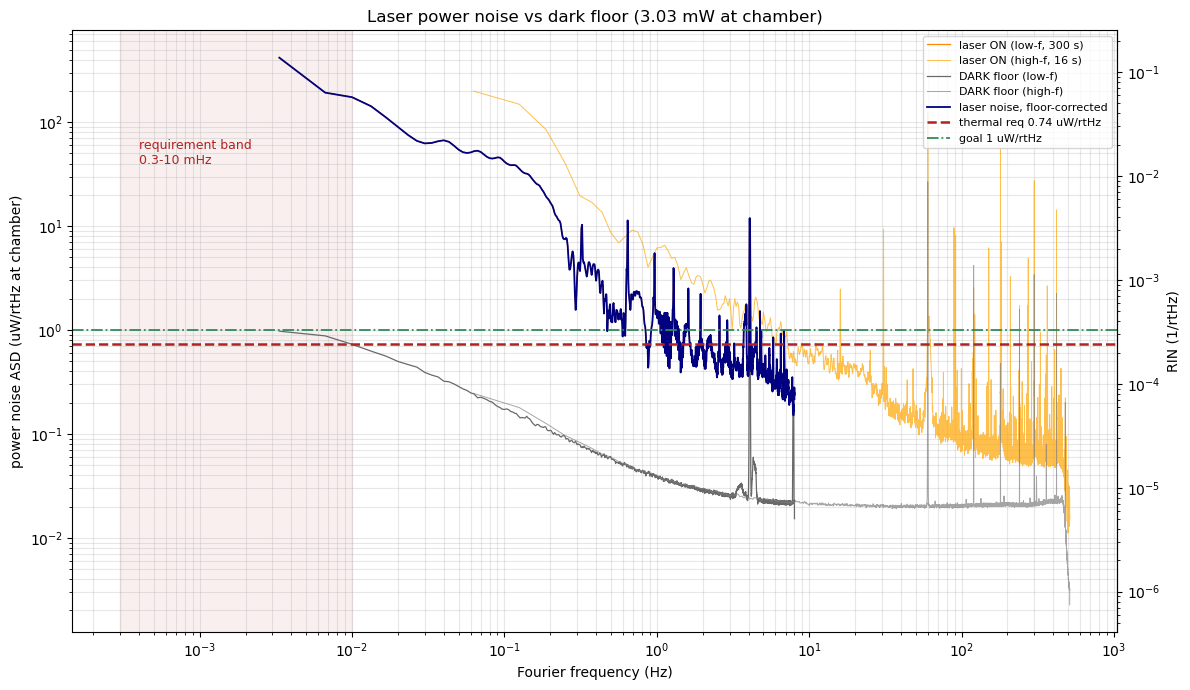

In [4]:
uw_on_hi = to_uW(on['P_hi'], CTS_PER_MW); uw_dk_hi = to_uW(dk['P_hi'], CTS_PER_MW)
uw_on_lo = to_uW(on['P_lo'], CTS_PER_MW); uw_dk_lo = to_uW(dk['P_lo'], CTS_PER_MW)
uw_ex_hi = to_uW(np.clip(on['P_hi'] - dk['P_hi'], 0, None), CTS_PER_MW)
uw_ex_lo = to_uW(np.clip(on['P_lo'] - dk['P_lo'], 0, None), CTS_PER_MW)
f_hi, f_lo = on['f_hi'], on['f_lo']

fig, ax = plt.subplots(figsize=(12, 7))
ax.loglog(f_lo[1:], uw_on_lo[1:], lw=0.9, color='darkorange', label='laser ON (low-f, 300 s)')
ax.loglog(f_hi[1:], uw_on_hi[1:], lw=0.7, color='orange', alpha=0.7, label='laser ON (high-f, 16 s)')
ax.loglog(f_lo[1:], uw_dk_lo[1:], lw=0.9, color='dimgray', label='DARK floor (low-f)')
ax.loglog(f_hi[1:], uw_dk_hi[1:], lw=0.7, color='gray', alpha=0.7, label='DARK floor (high-f)')
ax.loglog(f_lo[1:], uw_ex_lo[1:], lw=1.3, color='navy', label='laser noise, floor-corrected')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.8, label=f'thermal req {REQ_UW:.2f} uW/rtHz')
ax.axhline(TARGET_UW, color='seagreen', ls='-.', lw=1.3, label=f'goal {TARGET_UW:.0f} uW/rtHz')
ax.axvspan(3e-4, 1e-2, color='firebrick', alpha=0.07)
ax.text(4e-4, 4e1, 'requirement band\n0.3-10 mHz', fontsize=9, color='firebrick')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('power noise ASD (uW/rtHz at chamber)')
ax.set_title(f'Laser power noise vs dark floor ({P_CHAMBER_MW:.2f} mW at chamber)')
sec = ax.secondary_yaxis('right', functions=(lambda x: x*1e-3/P_CHAMBER_MW,
                                             lambda r: r*P_CHAMBER_MW*1e3))
sec.set_ylabel('RIN (1/rtHz)')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

### Broadband levels by band — and where the detector floor dominates

In [5]:
print(f"{'band (Hz)':>15} | {'ON':>9} | {'DARK':>9} | {'laser':>9} | {'laser/req':>9} | detector-limited?")
print('-'*90)
for lo, hi, src in [(0.003,0.01,'lo'),(0.01,0.1,'lo'),(0.1,0.5,'lo'),(0.5,2,'hi'),
                    (2,10,'hi'),(10,50,'hi'),(50,200,'hi'),(200,500,'hi')]:
    ff,uon,udk,uex = (f_lo,uw_on_lo,uw_dk_lo,uw_ex_lo) if src=='lo' else (f_hi,uw_on_hi,uw_dk_hi,uw_ex_hi)
    b = (ff>lo)&(ff<hi)
    if not b.any(): continue
    on_m,dk_m,ex_m = np.median(uon[b]),np.median(udk[b]),np.median(uex[b])
    lim = 'YES (floor dominates)' if dk_m>0.5*on_m else 'no'
    print(f'{lo:6.3f}-{hi:6.3f} | {on_m:9.4f} | {dk_m:9.4f} | {ex_m:9.4f} | {ex_m/REQ_UW:8.2f}x | {lim}')

      band (Hz) |        ON |      DARK |     laser | laser/req | detector-limited?
------------------------------------------------------------------------------------------
 0.003- 0.010 |  304.8704 |    0.9259 |  304.8688 |   414.62x | no
 0.010- 0.100 |   52.8839 |    0.2669 |   52.8834 |    71.92x | no
 0.100- 0.500 |    4.4675 |    0.0805 |    4.4668 |     6.07x | no
 0.500- 2.000 |    4.8981 |    0.0354 |    4.8980 |     6.66x | no
 2.000-10.000 |    0.9827 |    0.0229 |    0.9825 |     1.34x | no
10.000-50.000 |    0.2453 |    0.0203 |    0.2444 |     0.33x | no
50.000-200.000 |    0.0877 |    0.0206 |    0.0849 |     0.12x | no
200.000-500.000 |    0.0581 |    0.0214 |    0.0538 |     0.07x | no


## 3. Spectral lines (tagged *electronic* if also present in the dark record)

   f (Hz) |  ON uW/rtHz |  DARK uW/rtHz |   x req | origin
------------------------------------------------------------------
    59.94 |     124.843 |        26.740 |  169.8x | optical
   179.81 |      56.088 |         0.477 |   76.3x | optical
   299.69 |      27.376 |         3.411 |   37.2x | optical
   419.50 |      14.292 |         2.113 |   19.4x | optical
    89.12 |       9.645 |         0.020 |   13.1x | optical
    30.69 |       9.328 |         0.021 |   12.7x | optical
    91.25 |       8.168 |         0.020 |   11.1x | optical
   182.50 |       7.043 |         0.021 |    9.6x | optical
   150.56 |       6.155 |         0.021 |    8.4x | optical
   273.75 |       4.877 |         0.021 |    6.6x | optical
   209.00 |       3.262 |         0.020 |    4.4x | optical
   365.00 |       2.657 |         0.022 |    3.6x | optical
   119.88 |       2.546 |         4.184 |    3.5x | electronic (in dark)
   270.44 |       1.718 |         0.021 |    2.3x | optical
   239.75 |       1.7

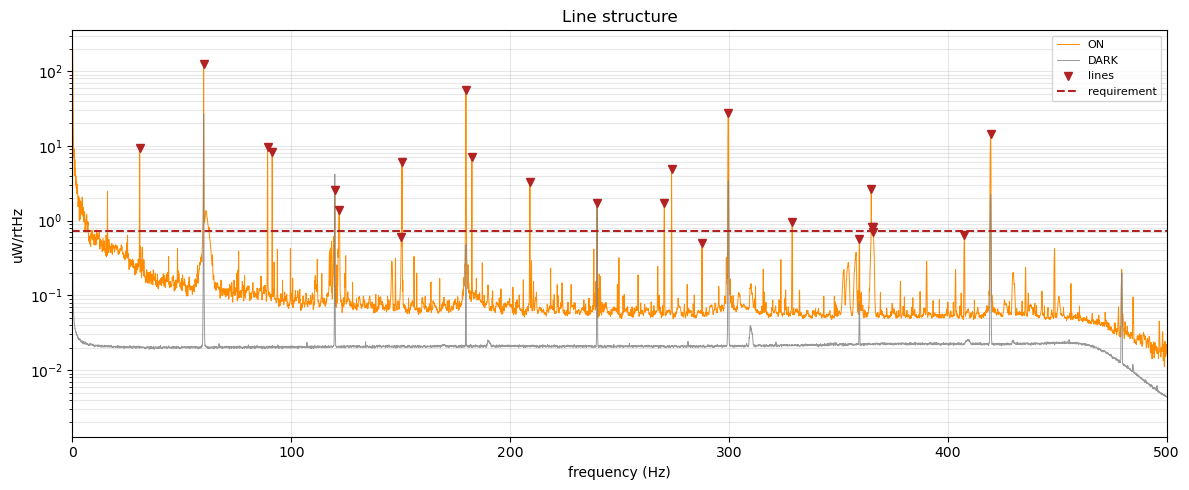

In [6]:
m = f_hi > 0.2
fm, um_on, um_dk = f_hi[m], uw_on_hi[m], uw_dk_hi[m]
base = median_filter(um_on, size=101)
pk, _ = find_peaks(um_on/base, height=8, distance=3)
order = np.argsort(um_on[pk])[::-1]
print(f"{'f (Hz)':>9} | {'ON uW/rtHz':>11} | {'DARK uW/rtHz':>13} | {'x req':>7} | origin")
print('-'*66)
for i in pk[order][:15]:
    electronic = um_dk[i] > 0.5*um_on[i]
    print(f'{fm[i]:9.2f} | {um_on[i]:11.3f} | {um_dk[i]:13.3f} | {um_on[i]/REQ_UW:6.1f}x | '
          f'{"electronic (in dark)" if electronic else "optical"}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(f_hi[1:], uw_on_hi[1:], lw=0.7, color='darkorange', label='ON')
ax.semilogy(f_hi[1:], uw_dk_hi[1:], lw=0.7, color='gray', alpha=0.8, label='DARK')
ax.semilogy(fm[pk], um_on[pk], 'v', ms=6, color='firebrick', label='lines')
ax.axhline(REQ_UW, color='firebrick', ls='--', lw=1.5, label='requirement')
ax.set_xlim(0, 500); ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('uW/rtHz')
ax.set_title('Line structure'); ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. PD vs power meter

Both measure the same laser power. The meter's internal clock is wrong (StarLab header reads
2006), so the series are aligned by cross-correlating fluctuations on a common grid rather than
by absolute timestamp. The means agree by construction (that is the calibration); the useful
comparison is the **stability** (std) and any common slow drift.

meter mean 3.0307 mW  vs  PD mean 3.0288 mW
meter std  6.32 uW (~15 Hz)  vs  PD std 87.13 uW (16 Hz)
best-fit lag -17821 s   correlation r = 0.063  (low r expected if laser was flat)


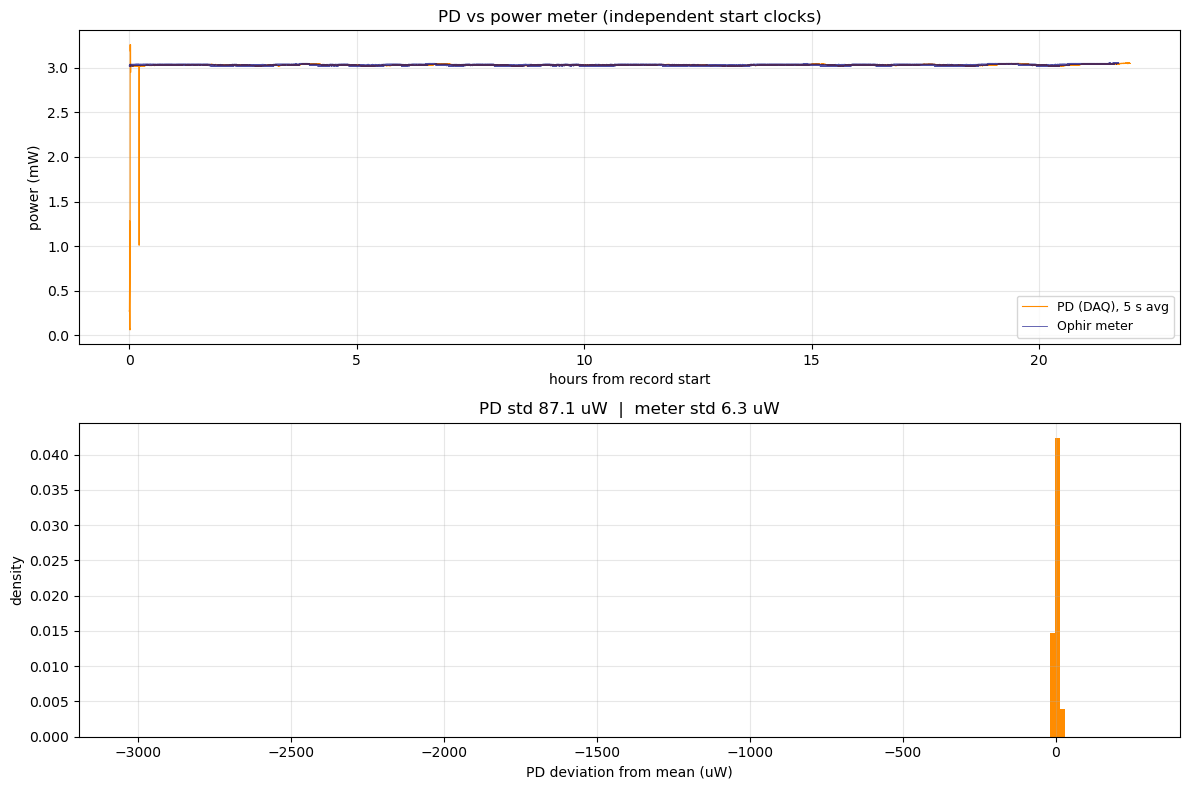

In [7]:
gp = np.arange(0, min(on['dur'], tm_s[-1]-tm_s[0]))
pd_1hz = np.interp(gp, on['t_lo']-on['t_lo'][0], on['mW_lo'])
pm_1hz = np.interp(gp, tm_s-tm_s[0], pm_mW)
a, b = pd_1hz-pd_1hz.mean(), pm_1hz-pm_1hz.mean()
if a.std()>0 and b.std()>0:
    xc = correlate(a, b, mode='full')
    lag = int(np.arange(-len(a)+1, len(a))[np.argmax(xc)])
    s, s2 = slice(max(0,lag),None), slice(max(0,-lag),None)
    nlap = min(len(a[s]), len(b[s2]))
    r = float(np.corrcoef(a[s][:nlap], b[s2][:nlap])[0,1]) if nlap>10 else float('nan')
else:
    lag, r = 0, float('nan')
print(f'meter mean {meter_mean_mW:.4f} mW  vs  PD mean {np.mean(on["mW_lo"]):.4f} mW')
print(f'meter std  {np.std(pm_mW)*1e3:.2f} uW (~15 Hz)  vs  PD std {np.std(on["mW_lo"])*1e3:.2f} uW ({FS_LO} Hz)')
print(f'best-fit lag {lag} s   correlation r = {r:.3f}  (low r expected if laser was flat)')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot((on['t_lo']-on['t_lo'][0])/3600, uniform_filter1d(on['mW_lo'], 5*FS_LO),
             lw=0.8, color='darkorange', label='PD (DAQ), 5 s avg')
axes[0].plot((tm_s-tm_s[0])/3600, pm_mW, lw=0.6, color='navy', alpha=0.7, label='Ophir meter')
axes[0].set_xlabel('hours from record start'); axes[0].set_ylabel('power (mW)')
axes[0].set_title('PD vs power meter (independent start clocks)'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
dev = (on['mW_lo']-np.mean(on['mW_lo']))*1e3
axes[1].hist(dev, bins=200, color='darkorange', density=True)
axes[1].set_xlabel('PD deviation from mean (uW)'); axes[1].set_ylabel('density')
axes[1].set_title(f'PD std {dev.std():.1f} uW  |  meter std {np.std(pm_mW)*1e3:.1f} uW')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Shot-noise context

In [8]:
hf = (f_hi>100)&(f_hi<400)
floor_uW = float(np.median(uw_on_hi[hf]))
floor_rin = floor_uW*1e-3/P_CHAMBER_MW
shot_rin = np.sqrt(2*E_CHARGE/(RESPONSIVITY*P_CHAMBER_MW*1e-3))
print(f'measured floor (100-400 Hz): {floor_uW:.4f} uW/rtHz = {floor_rin:.2e} /rtHz')
print(f'shot-noise RIN at {P_CHAMBER_MW:.2f} mW: {shot_rin:.2e} /rtHz')
print(f'measured floor is {floor_rin/shot_rin:.0f}x above shot noise (implementation-limited)')

measured floor (100-400 Hz): 0.0659 uW/rtHz = 2.17e-05 /rtHz
shot-noise RIN at 3.03 mW: 1.23e-08 /rtHz
measured floor is 1768x above shot noise (implementation-limited)
